# Injection-width resolution limits

Referee 2, comment 4: *"Around Eq. (9), have the authors tried to quantify what are the
lowest values of the injection width which can be resolved?"*

Two widths enter the burst-type scenarios:

* the **temporal** width $\sigma_z$ of the Gaussian in redshift (Eq. 9 for heat injection,
  and the $\mathcal{G}(z; z_h,\sigma_z)$ factor of Eq. 12 for monochromatic photon
  injection), default $\sigma_z = 0.04\,z_h$;
* the **spectral** width $\sigma_x$ of the injected line (photon injection only),
  default $\sigma_x = 0.05\,x_\mathrm{inj}$.

Neither width is resolution-limited in the naive sense, because both discretisations
adapt to it:

* $\sigma_z$: the adaptive stepper caps $\Delta z \le \sigma_z/10$ inside
  $|z - z_h| < 5\sigma_z$ (`solver.rs`), so the temporal profile is covered by
  $\gtrsim 100$ steps *for any* $\sigma_z$.  Narrow bursts cost more steps, they are not
  smeared out.
* $\sigma_x$: `InjectionScenario::refinement_zones` inserts 300 extra grid points inside
  $x_\mathrm{inj} \pm 5\sigma_x$ for *every* monochromatic-photon run, so the local
  spacing is $\Delta x \approx 10\sigma_x/300 = \sigma_x/30$ — again independent of
  $\sigma_x$.  Without that zone (`--no-auto-refine`) the base grid at
  $x_\mathrm{inj} = 1$, $N = 8000$ gives $\Delta x \approx 4.7\times 10^{-3}$, i.e.
  $\approx 11$ points per default $\sigma_x$ and none at
  $\sigma_x \lesssim 0.005\,x_\mathrm{inj}$.

What is left to quantify is therefore not a hard resolution floor but the *sensitivity*
of the answer to the width: how narrow one must go before $\mu$, $y$ and the spectrum
stop changing (the instantaneous / monochromatic limit), and how wide one may go before
the finite width is physically visible.  This notebook scans both widths and reports
(i) the change in the intensity distortion shape relative to the default parameters and
(ii) the change in $\mu$ and $y$.
Output: `notebooks/figures/injection_width_resolution.pdf`.

In [1]:
import os
import pickle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

import numpy as np
import matplotlib.pyplot as plt

from spectroxide import (
    solve, strip_gbb, delta_n_to_delta_I, G2_PLANCK, G3_PLANCK,
    apply_style, C, DOUBLE_COL,
)
from spectroxide.plot_params import LW, LW_THIN, LW_AXIS, LEGEND_SIZE, ANNOT_SIZE, SAVE_DPI

apply_style()

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)
CACHE = Path.cwd() / '.injection_width_cache.pkl'

# ── Scan configuration ────────────────────────────────────────────────
Z_H = 2e5                 # mu-era burst, where mu is largest
DELTA_RHO = 1e-5          # heat injection amplitude
X_INJ = 1.0               # photon injection frequency
DN_OVER_N = 1e-5          # photon injection amplitude
N_POINTS = 8000           # frequency grid points (photon runs)
F_SIGMA_Z_DEF = 0.04      # default sigma_z / z_h
F_SIGMA_X_DEF = 0.05      # default sigma_x / x_inj

# sigma_z / z_h values.  0.3 is the hard upper limit enforced by
# InjectionScenario::validate (narrow-Gaussian approximation).
FRAC_SZ_HEAT = [0.001, 0.002, 0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.25]
FRAC_SZ_PHOT = [0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.25]
# sigma_x / x_inj values, and the grid resolutions to test them at
FRAC_SX = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
SX_CONVERGENCE = [(0.005, 16000), (0.01, 16000), (0.02, 16000)]
# Cross-check that the sigma_z conclusions are not specific to the mu-era:
# same scan (fewer widths) for a y-era burst.
Z_H_YERA = 1e4
FRAC_SZ_YERA = [0.002, 0.005, 0.02, 0.04, 0.15]

# All runs in a scan share one z_start so that the pre-injection history
# (and its small adiabatic-cooling mu) is identical and cancels in the
# residuals.  7 sigma above the widest burst considered.
Z_START = Z_H * (1.0 + 7.0 * max(FRAC_SZ_HEAT + FRAC_SZ_PHOT))
Z_START_YERA = Z_H_YERA * (1.0 + 7.0 * max(FRAC_SZ_YERA))
N_WORKERS = 5

# Common comparison grid.  The solver grid depends on sigma_x (the
# refinement zone moves with it), so all shape residuals are taken on a
# fixed grid, finer than the base spacing everywhere it is plotted.
X_CMP = np.logspace(np.log10(0.02), np.log10(20.0), 1500)
NU_CMP, _ = delta_n_to_delta_I(X_CMP, np.zeros_like(X_CMP))

print(f'z_start = {Z_START:.3e} (common to all runs)')
print(f'default sigma_z = {F_SIGMA_Z_DEF * Z_H:.0f}, '
      f'default sigma_x = {F_SIGMA_X_DEF * X_INJ:.3f}')

z_start = 5.500e+05 (common to all runs)
default sigma_z = 8000, default sigma_x = 0.050


## Solver wrappers

`heat` uses the number-conserving PDE mode (so $\int x^2\Delta n\,dx = 0$ automatically);
`photon` runs with `number_conserving=False, nc_z_min=0` — the convention of the
photon-injection figure in the paper — and the $G_\mathrm{bb}$ temperature shift is
removed post hoc, which puts both cases in the same number-conserving gauge.

In [2]:
def run_heat(f_sigma_z, z_h=Z_H, z_start=Z_START):
    r = solve(
        injection={'type': 'single_burst', 'z_h': z_h, 'sigma_z': f_sigma_z * z_h},
        delta_rho=DELTA_RHO,
        z_start=z_start, z_end=500.0,
        timeout=3600,
    )
    return dict(x=r.x, dn=r.delta_n, mu=r.mu, y=r.y, drho=r.delta_rho_over_rho)


def run_photon(f_sigma_z, f_sigma_x, n_points=N_POINTS):
    r = solve(
        injection={'type': 'monochromatic_photon', 'x_inj': X_INJ,
                   'delta_n_over_n': DN_OVER_N, 'z_h': Z_H,
                   'sigma_z': f_sigma_z * Z_H, 'sigma_x': f_sigma_x * X_INJ},
        z_start=Z_START, z_end=50.0,
        n_points=n_points, number_conserving=False, nc_z_min=0,
        timeout=3600,
    )
    dn_nc, dt = strip_gbb(r.x, r.delta_n)
    return dict(x=r.x, dn=dn_nc, dn_raw=r.delta_n, delta_t=dt,
                mu=r.mu, y=r.y, drho=r.delta_rho_over_rho)


def build_jobs():
    # (key, callable) pairs for every PDE run needed below.
    jobs = []
    for f in FRAC_SZ_HEAT:
        jobs.append((('heat_sz', f), lambda f=f: run_heat(f)))
    for f in FRAC_SZ_YERA:
        jobs.append((('heat_yera', f),
                     lambda f=f: run_heat(f, z_h=Z_H_YERA, z_start=Z_START_YERA)))
    for f in FRAC_SZ_PHOT:
        jobs.append((('phot_sz', f, N_POINTS),
                     lambda f=f: run_photon(f, F_SIGMA_X_DEF)))
    for f in FRAC_SX:
        jobs.append((('phot_sx', f, N_POINTS),
                     lambda f=f: run_photon(F_SIGMA_Z_DEF, f)))
    for f, n in SX_CONVERGENCE:
        jobs.append((('phot_sx', f, n),
                     lambda f=f, n=n: run_photon(F_SIGMA_Z_DEF, f, n_points=n)))
    return jobs


def run_all(jobs, cache_path=CACHE):
    # Run every job not already cached, in parallel; cache to disk.
    data = pickle.loads(cache_path.read_bytes()) if cache_path.exists() else {}
    todo = [(k, fn) for k, fn in jobs if k not in data]
    print(f'{len(data)} cached, {len(todo)} to run')
    if not todo:
        return data
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(fn): k for k, fn in todo}
        for i, fut in enumerate(as_completed(futs), 1):
            k = futs[fut]
            data[k] = fut.result()
            print(f'  [{i}/{len(todo)}] {k}: mu={data[k]["mu"]:+.5e} '
                  f'y={data[k]["y"]:+.5e}  ({time.time() - t0:.0f}s elapsed)',
                  flush=True)
            cache_path.write_bytes(pickle.dumps(data))
    print(f'total {time.time() - t0:.0f}s')
    return data

## Run the scans

In [3]:
DATA = run_all(build_jobs())

0 cached, 30 to run
  [1/30] ('heat_sz', 0.005): mu=+1.39042e-05 y=+6.34626e-07  (20s elapsed)
  [2/30] ('heat_sz', 0.01): mu=+1.39037e-05 y=+6.34991e-07  (20s elapsed)
  [3/30] ('heat_sz', 0.001): mu=+1.39432e-05 y=+6.36109e-07  (20s elapsed)
  [4/30] ('heat_sz', 0.002): mu=+1.39152e-05 y=+6.34965e-07  (21s elapsed)
  [5/30] ('heat_sz', 0.02): mu=+1.39018e-05 y=+6.36456e-07  (21s elapsed)
  [6/30] ('heat_yera', 0.002): mu=+1.92164e-08 y=+2.59602e-06  (21s elapsed)
  [7/30] ('heat_yera', 0.005): mu=+1.92078e-08 y=+2.59559e-06  (22s elapsed)
  [8/30] ('heat_yera', 0.02): mu=+1.91684e-08 y=+2.59316e-06  (23s elapsed)
  [9/30] ('heat_yera', 0.04): mu=+1.91365e-08 y=+2.58995e-06  (24s elapsed)
  [10/30] ('heat_yera', 0.15): mu=+1.97131e-08 y=+2.59054e-06  (24s elapsed)
  [11/30] ('heat_sz', 0.04): mu=+1.38941e-05 y=+6.42358e-07  (45s elapsed)
  [12/30] ('heat_sz', 0.15): mu=+1.37340e-05 y=+7.53864e-07  (46s elapsed)
  [13/30] ('heat_sz', 0.08): mu=+1.38618e-05 y=+6.66579e-07  (47s elapsed)

## Diagnostics

Two normalisations are reported per scan.  Absolute $\mu$ and $y$ mix two effects: the
response of the medium to a burst of a given duration, and the fraction of the injected
energy that survives as a distortion rather than thermalising into a temperature shift
(the recovered $\Delta\rho/\rho$).  The ratio $\mu/(\Delta\rho/\rho)$ isolates the
former and is the quantity a Green's-function comparison actually tests.

The frequency-grid spacing at $x_\mathrm{inj}$ sets the smallest resolvable spectral
width.  `pts_per_sigma` below is $\sigma_x/\Delta x$ at $x = x_\mathrm{inj}$ (inside the
refinement zone, hence $\approx 30$ for any $\sigma_x$); the
injected energy check compares the recovered $\Delta\rho/\rho$ against the analytic
value for a normalised Gaussian line,
$\Delta\rho/\rho = (\Delta N/N)\,(G_2/G_3)\,x_\mathrm{inj}$
(exact up to thermalisation losses between $z_h$ and $z_\mathrm{end}$).

In [4]:
def dx_at(x, x0):
    i = int(np.argmin(np.abs(x - x0)))
    return float(x[min(i + 1, len(x) - 1)] - x[max(i - 1, 0)]) / 2.0


drho_analytic = DN_OVER_N * (G2_PLANCK / G3_PLANCK) * X_INJ
print(f'analytic injected energy  drho/rho = {drho_analytic:.5e}\n')

print(f'{"sigma_x/x_inj":>13s} {"N":>6s} {"dx(x_inj)":>10s} {"pts/sigma":>10s} '
      f'{"mu":>12s} {"y":>12s} {"drho/analytic-1":>16s}')
for k in sorted(DATA):
    if k[0] != 'phot_sx':
        continue
    f, n, d = k[1], k[2], DATA[k]
    dx = dx_at(d['x'], X_INJ)
    print(f'{f:13.3f} {n:6d} {dx:10.2e} {f * X_INJ / dx:10.2f} '
          f'{d["mu"]:+12.4e} {d["y"]:+12.4e} '
          f'{d["drho"] / drho_analytic - 1:+15.2%}')

analytic injected energy  drho/rho = 3.70209e-06

sigma_x/x_inj      N  dx(x_inj)  pts/sigma           mu            y  drho/analytic-1
        0.005   8000   1.67e-04      29.90  -1.3545e-05  -5.1763e-07          -0.11%
        0.005  16000   1.67e-04      29.90  -1.3549e-05  -5.1383e-07          -0.10%
        0.010   8000   3.26e-04      30.66  -1.3545e-05  -5.1757e-07          -0.11%
        0.010  16000   3.35e-04      29.88  -1.3549e-05  -5.1377e-07          -0.10%
        0.020   8000   4.50e-04      44.44  -1.3545e-05  -5.1734e-07          -0.11%
        0.020  16000   6.71e-04      29.80  -1.3550e-05  -5.1355e-07          -0.10%
        0.050   8000   8.54e-04      58.52  -1.3546e-05  -5.1575e-07          -0.11%
        0.100   8000   1.84e-03      54.46  -1.3550e-05  -5.1012e-07          -0.11%
        0.200   8000   2.89e-03      69.27  -1.3569e-05  -4.8163e-07          -0.11%


In [5]:
def dI_cmp(d):
    # Intensity distortion [Jy/sr] on the common grid NU_CMP.
    nu, dI = delta_n_to_delta_I(d['x'], d['dn'])
    return np.interp(NU_CMP, nu, dI)


def scan(kind, n=N_POINTS):
    # Sorted (frac, result) pairs for one scan at one grid resolution.
    out = []
    for k in sorted(DATA, key=lambda t: t[1]):
        if k[0] != kind:
            continue
        if len(k) > 2 and k[2] != n:
            continue
        out.append((k[1], DATA[k]))
    return out


for kind, label, f_def in (('heat_sz', f'heat z_h={Z_H:.0e}, sigma_z/z_h', F_SIGMA_Z_DEF),
                           ('heat_yera', f'heat z_h={Z_H_YERA:.0e}, sigma_z/z_h', F_SIGMA_Z_DEF),
                           ('phot_sz', 'photon, sigma_z/z_h', F_SIGMA_Z_DEF),
                           ('phot_sx', 'photon, sigma_x/x_inj', F_SIGMA_X_DEF)):
    rows = scan(kind)
    ref = dict(rows)[f_def]
    print(f'\n{label}  (deviation w.r.t. default = {f_def})')
    print(f'{"frac":>8s} {"mu":>13s} {"dmu [%]":>9s} {"y":>13s} {"dy [%]":>9s} '
          f'{"d(drho) [%]":>12s} {"d(mu/drho) [%]":>15s} {"max|dI| [%peak]":>16s}')
    dIg = dI_cmp(ref)
    peak = np.max(np.abs(dIg))
    ref_resp = ref['mu'] / ref['drho']
    for f, d in rows:
        resid = 100.0 * np.max(np.abs(dI_cmp(d) - dIg)) / peak
        print(f'{f:8.3f} {d["mu"]:+13.5e} {100 * (d["mu"] / ref["mu"] - 1):+9.3f} '
              f'{d["y"]:+13.5e} {100 * (d["y"] / ref["y"] - 1):+9.3f} '
              f'{100 * (d["drho"] / ref["drho"] - 1):+12.4f} '
              f'{100 * (d["mu"] / d["drho"] / ref_resp - 1):+15.4f} {resid:16.3f}')
    print(f'  peak |dI| (default) = {peak:.3f} Jy/sr, '
          f'drho(default) = {ref["drho"]:.6e}')


heat z_h=2e+05, sigma_z/z_h  (deviation w.r.t. default = 0.04)
    frac            mu   dmu [%]             y    dy [%]  d(drho) [%]  d(mu/drho) [%]  max|dI| [%peak]
   0.001  +1.39432e-05    +0.353  +6.36109e-07    -0.973      +0.2789         +0.0741            0.265
   0.002  +1.39152e-05    +0.151  +6.34965e-07    -1.151      +0.0778         +0.0734            0.070
   0.005  +1.39042e-05    +0.073  +6.34626e-07    -1.204      +0.0003         +0.0722            0.047
   0.010  +1.39037e-05    +0.069  +6.34991e-07    -1.147      +0.0003         +0.0688            0.045
   0.020  +1.39018e-05    +0.055  +6.36456e-07    -0.919      +0.0002         +0.0552            0.036
   0.040  +1.38941e-05    +0.000  +6.42358e-07    +0.000      +0.0000         +0.0000            0.000
   0.080  +1.38618e-05    -0.233  +6.66579e-07    +3.771      -0.0003         -0.2325            0.147
   0.150  +1.37340e-05    -1.152  +7.53864e-07   +17.359      -0.0010         -1.1512            0.679
   0.250 

## Figure

wrote /home/bakerem/spectroxide/notebooks/figures/injection_width_resolution.pdf


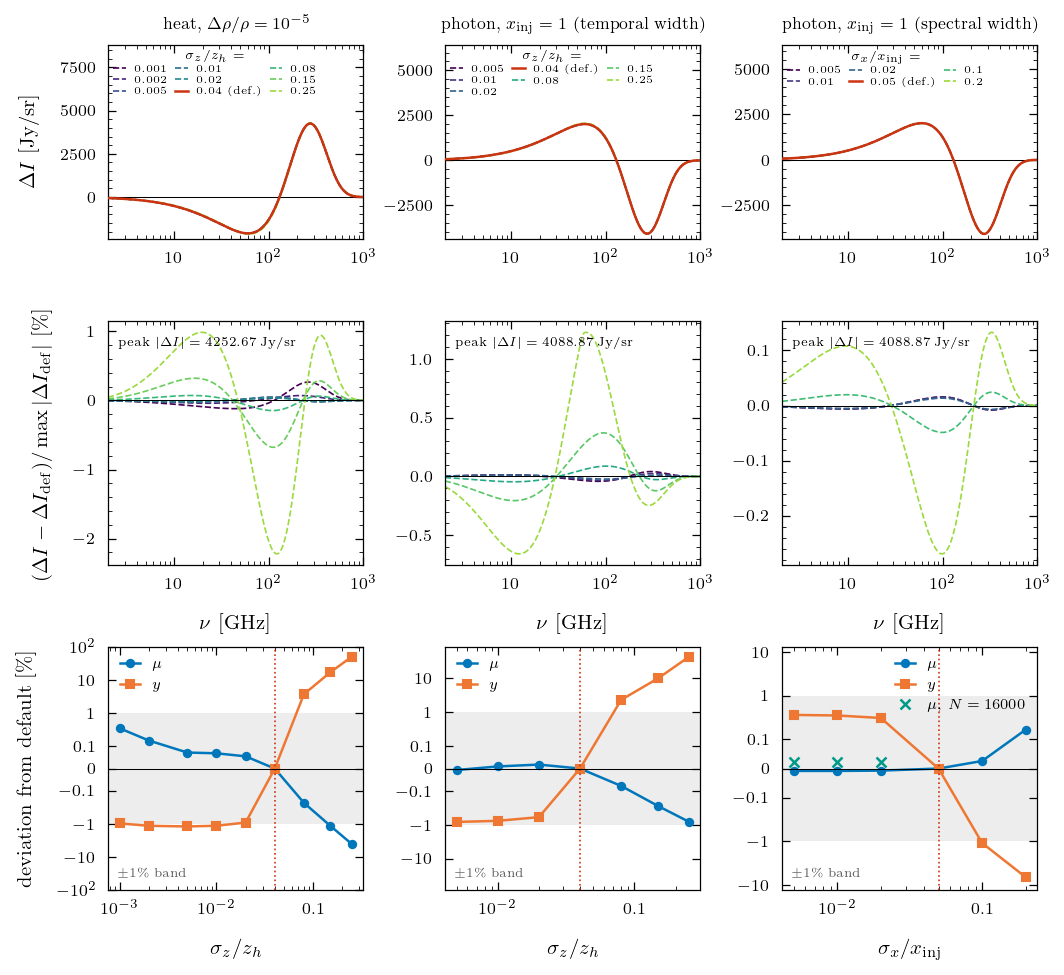

In [6]:
apply_style()

PANELS = [
    dict(kind='heat_sz', fracs=FRAC_SZ_HEAT, f_def=F_SIGMA_Z_DEF,
         xlabel=r'$\sigma_z / z_h$',
         title=r'heat, $\Delta\rho/\rho=10^{-5}$',
         wlabel=r'$\sigma_z/z_h$'),
    dict(kind='phot_sz', fracs=FRAC_SZ_PHOT, f_def=F_SIGMA_Z_DEF,
         xlabel=r'$\sigma_z / z_h$',
         title=r'photon, $x_\mathrm{inj}=1$ (temporal width)',
         wlabel=r'$\sigma_z/z_h$'),
    dict(kind='phot_sx', fracs=FRAC_SX, f_def=F_SIGMA_X_DEF,
         xlabel=r'$\sigma_x / x_\mathrm{inj}$',
         title=r'photon, $x_\mathrm{inj}=1$ (spectral width)',
         wlabel=r'$\sigma_x/x_\mathrm{inj}$'),
]

fig, axes = plt.subplots(3, 3, figsize=(DOUBLE_COL, 6.4),
                         gridspec_kw=dict(height_ratios=[0.8, 1.0, 1.0]))

for col, P in enumerate(PANELS):
    rows = dict(scan(P['kind']))
    ref = rows[P['f_def']]
    dI_ref = dI_cmp(ref)
    peak = np.max(np.abs(dI_ref))

    cmap = plt.get_cmap('viridis')
    lognorm = np.log10(np.array(P['fracs']))
    cnorm = (lognorm - lognorm.min()) / np.ptp(lognorm)

    ax0, ax1, ax2 = axes[0, col], axes[1, col], axes[2, col]

    # ── Row 1: intensity distortion ──
    for f, cn in zip(P['fracs'], cnorm):
        d = rows[f]
        is_def = f == P['f_def']
        ax0.plot(NU_CMP, dI_cmp(d),
                 color=C['red'] if is_def else cmap(0.85 * cn),
                 lw=LW if is_def else LW_THIN,
                 ls='-' if is_def else '--',
                 zorder=5 if is_def else 2,
                 label=rf'${f:g}$' + (' (def.)' if is_def else ''))
    ax0.set_xscale('log')
    ax0.set_xlim(2, 1000)
    ax0.axhline(0, color='k', lw=LW_AXIS)
    ax0.set_title(P['title'], fontsize=ANNOT_SIZE + 1)
    lo, hi = ax0.get_ylim()
    ax0.set_ylim(lo, hi + 0.6 * (hi - lo))  # headroom for the legend
    leg = ax0.legend(fontsize=LEGEND_SIZE - 2, frameon=False, ncol=3,
                     loc='upper left', handlelength=1.2, labelspacing=0.2,
                     columnspacing=0.8, borderaxespad=0.2,
                     title=P['wlabel'] + ' $=$')
    leg.get_title().set_fontsize(LEGEND_SIZE - 1)
    if col == 0:
        ax0.set_ylabel(r'$\Delta I$ [Jy/sr]')

    # ── Row 2: residual w.r.t. default ──
    for f, cn in zip(P['fracs'], cnorm):
        d = rows[f]
        if f == P['f_def']:
            continue
        ax1.plot(NU_CMP, 100.0 * (dI_cmp(d) - dI_ref) / peak,
                 color=cmap(0.85 * cn), lw=LW_THIN, ls='--')
    ax1.set_xscale('log')
    ax1.set_xlim(2, 1000)
    ax1.axhline(0, color='k', lw=LW_AXIS)
    ax1.set_xlabel(r'$\nu$ [GHz]')
    ax1.annotate(rf'peak $|\Delta I|={peak:.2f}$ Jy/sr', xy=(0.04, 0.9),
                 xycoords='axes fraction', fontsize=ANNOT_SIZE - 1)
    if col == 0:
        ax1.set_ylabel(r'$(\Delta I - \Delta I_\mathrm{def})/\max|\Delta I_\mathrm{def}|$ [\%]')

    # ── Row 3: mu, y vs width ──
    fr = np.array(P['fracs'])
    mu = np.array([rows[f]['mu'] for f in P['fracs']])
    yy = np.array([rows[f]['y'] for f in P['fracs']])
    ax2.plot(fr, 100.0 * (mu / ref['mu'] - 1), 'o-', color=C['blue'],
             lw=LW, ms=3.5, label=r'$\mu$')
    ax2.plot(fr, 100.0 * (yy / ref['y'] - 1), 's-', color=C['orange'],
             lw=LW, ms=3.5, label=r'$y$')
    if P['kind'] == 'phot_sx':
        for f, n in SX_CONVERGENCE:
            k = ('phot_sx', f, n)
            if k in DATA:
                ax2.plot([f], [100.0 * (DATA[k]['mu'] / ref['mu'] - 1)], 'x',
                         color=C['teal'], ms=5, mew=1.2,
                         label=r'$\mu$, $N=16000$' if f == SX_CONVERGENCE[0][0] else None)
    ax2.axvline(P['f_def'], color=C['red'], lw=LW_THIN, ls=':')
    ax2.axhline(0, color='k', lw=LW_AXIS)
    ax2.axhspan(-1, 1, color=C['gray'], alpha=0.25, lw=0, zorder=0)
    ax2.set_xscale('log')
    ax2.set_yscale('symlog', linthresh=0.1, linscale=0.6)
    lim = 2.0 * max(np.max(np.abs(100 * (mu / ref['mu'] - 1))),
                    np.max(np.abs(100 * (yy / ref['y'] - 1))), 1.0)
    ax2.set_ylim(-lim, lim)
    ax2.annotate(r'$\pm1\%$ band', xy=(0.04, 0.06), xycoords='axes fraction',
                 fontsize=ANNOT_SIZE - 1, color='0.35')
    ax2.set_xlabel(P['xlabel'])
    ax2.legend(fontsize=LEGEND_SIZE, frameon=False, loc='best', handlelength=1.4)
    if col == 0:
        ax2.set_ylabel(r'deviation from default [\%]')

fig.tight_layout(pad=0.4)
out = FIG_DIR / 'injection_width_resolution.pdf'
fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
print(f'wrote {out}')
plt.show()